In [21]:
import os

import pandas as pd
import numpy as np
import xarray as xr

from bluemath_tk.teslakit.alr import ALR_WRP

import seaborn as sns
import matplotlib.pyplot as plt

#### Load Data

In [22]:
#### Tracks
hist_tracks = xr.open_dataset('inputs/ibtracs_na_tracks.nc')
track_types = pd.read_csv('inputs/track_types_hist.csv')

#### Principal Components
era5_pcs_mslp = pd.read_csv('outputs/era5/era5_mslp_pcs.csv', index_col=0, parse_dates=True)
era5_pcs_mslp = era5_pcs_mslp.iloc[:,:10]
era5_pcs_sst = pd.read_csv('outputs/era5/era5_sst_pcs.csv', index_col=0, parse_dates=True)


In [23]:
def detrend_dataframe(df, degree=1):
    """
    Detrend each column of a DataFrame using polynomial fit.

    Parameters:
    - df: DataFrame (columns = PCs, rows = time)
    - degree: 1 = linear, 2 = quadratic

    Returns:
    - detrended DataFrame
    """
    x = np.arange(len(df))  # time index

    df_detrended = pd.DataFrame(index=df.index, columns=df.columns)

    for col in df.columns:
        y = df[col].values

        # fit polynomial
        coeffs = np.polyfit(x, y, degree)
        trend = np.polyval(coeffs, x)

        # remove trend
        df_detrended[col] = y - trend

    return df_detrended

In [24]:
#### Remove LongTerm Trend
era5_pcs_sst_detrended = detrend_dataframe(era5_pcs_sst, degree=2)

In [25]:
era5_pcs_sst = era5_pcs_sst_detrended.copy()

#### Dates of Maximum Intensity

In [26]:
times_max_int = []

for track in hist_tracks.storm.values:
    track_ds = hist_tracks.sel(storm=track)
    time = track_ds.time.values
    pres = track_ds.wmo_pres.values

    min_pres_pos = np.nanargmin(pres)
    min_pres_pos = 0
    max_int_time = time[min_pres_pos]
    formatted = np.datetime_as_string(max_int_time, unit='D')
    times_max_int.append(formatted)

track_types['date'] = times_max_int

In [27]:
track_types.to_csv('outputs/ibtracs_na_tracks_max_int.csv', index=False)

#### Predictor 

In [28]:
#### 5 Day Average of PCs
era5_pcs_mslp_roll = era5_pcs_mslp.rolling("5D", center=True).mean()
era5_pcs_sst_roll = era5_pcs_sst.rolling("5D", center=True).mean()

era5_pcs_mslp_roll = era5_pcs_mslp_roll.add_suffix("_mslp")
era5_pcs_sst_roll = era5_pcs_sst_roll.add_suffix("_sst")

era5_pcs_roll = era5_pcs_mslp_roll.join(era5_pcs_sst_roll, how="inner")

#### Predictand

In [29]:
era5_pcs_roll['TrackType'] = 1

for i in range(len(track_types)):
    date = track_types['date'][i]
    tt = track_types['Track_Type'][i] + 2
    era5_pcs_roll.loc[date, 'TrackType'] = tt

#### Common Dates

In [30]:
date_min = hist_tracks.isel(storm=0).time.values[0]
era5_pcs_roll = era5_pcs_roll[era5_pcs_roll.index >= date_min]

#### Logistic Regression Model

In [31]:
covar_ds = era5_pcs_roll.iloc[:, :-1].to_xarray()
covar_ds = covar_ds.rename({'index':'time'})

In [32]:
nPCs = era5_pcs_roll.iloc[:, :-1].shape[1]
cov_names_list = era5_pcs_roll.iloc[:, :-1].columns.tolist()
cov_list = []

for i in range(nPCs):
    cov_list.append(covar_ds[cov_names_list[i]].values)
cov_combined = np.hstack([cov_list]).T  # shape (n_covariates, n_times)

cov_names_list = era5_pcs_roll.iloc[:, :-1].columns.tolist()
new_cov_norm = xr.DataArray(
    cov_combined,
    dims=["time", "n_covariates"],
    coords={
        "time": covar_ds.time.values,
        "n_covariates": np.arange(cov_combined.shape[1])  # [0, 1, 2, 3, 4]
    },
    name="cov_norm"
)

covariates_ds = new_cov_norm.to_dataset()
covariates_ds = (covariates_ds - covariates_ds.mean(dim="time")) / covariates_ds.std(
    dim="time"
)
covariates_ds["cov_names"] = (("n_covariates"), cov_names_list)

In [33]:
alr_model = ALR_WRP(
    p_base="/lustre/geocean/WORK/users/alonsoap/personal/mini_projects/stochastic_gcms_clean_nc/outputs/tc_logit"
)

alr_terms = {
    "mk_order": 0,
    "constant": True,
    "long_term": False,
    "seasonality": (False, [2]),
    "covariates": (
        True,
        covariates_ds,
    ),
}

nTT = track_types['Track_Type'].nunique() + 1 # +1 for the "no TC" type

df_bmus_fit = pd.DataFrame()
df_bmus_fit['time'] = covar_ds.time.values
df_bmus_fit['bmus'] = era5_pcs_roll.iloc[:, -1:].values.astype(int)
xds_bmus_fit = df_bmus_fit.set_index('time').to_xarray()

alr_model.SetFitData(
    cluster_size=int(nTT),
    xds_bmus_fit=xds_bmus_fit,
    d_terms_settings=alr_terms,
)

In [34]:
alr_model.FitModel()


Fitting autoregressive logistic model ...
Optimization done in 0.62 seconds



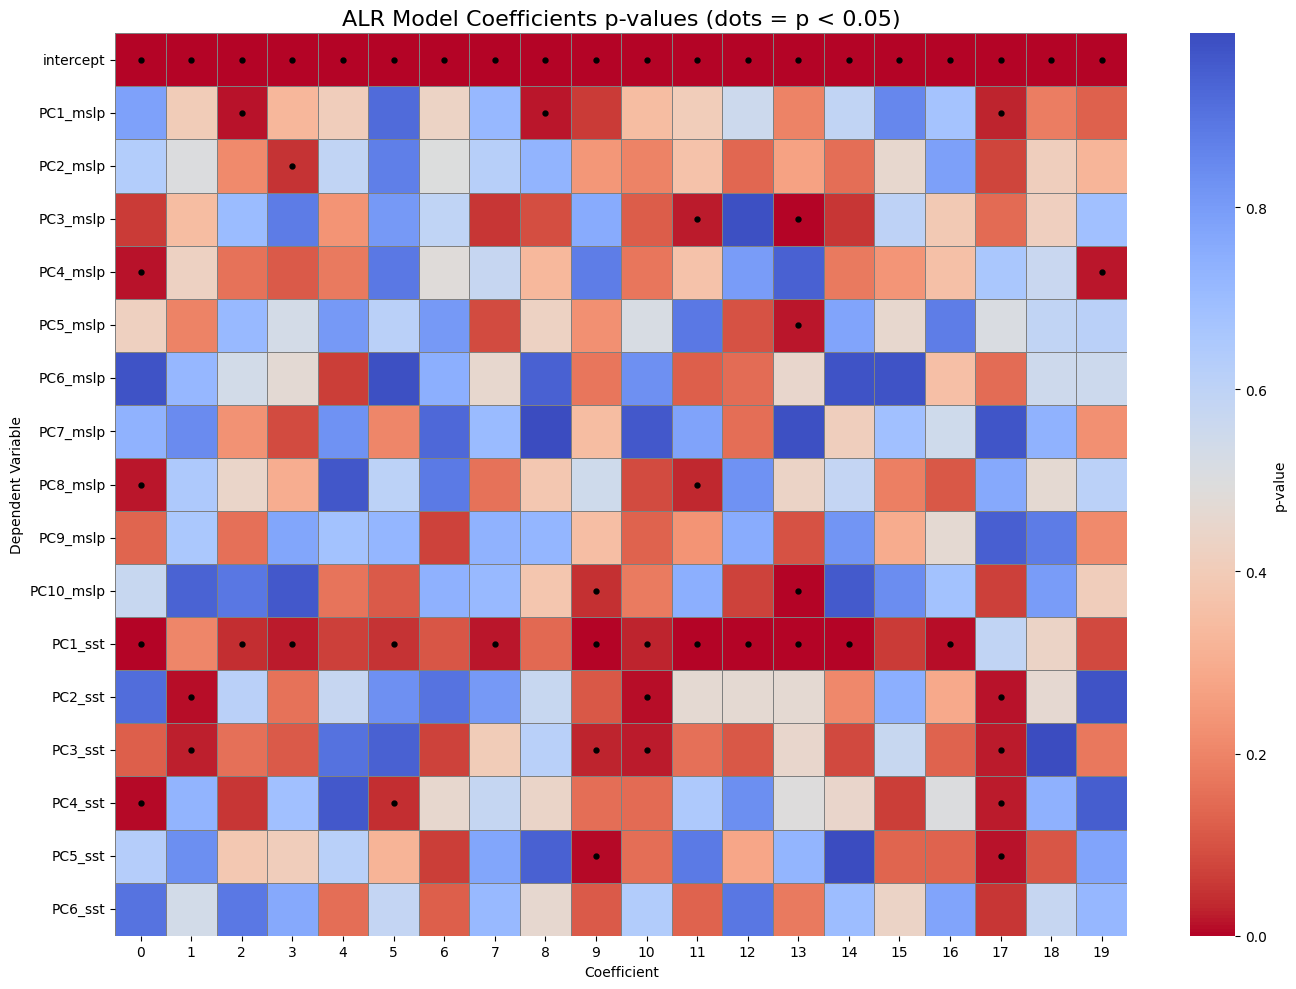

In [35]:
pvals = alr_model.model.pvalues

plt.figure(figsize=(14, 10))
sns.heatmap(pvals,cmap="coolwarm_r",linewidths=0.5,linecolor='gray',cbar_kws={'label': 'p-value'})

# Add black dots for significant coefficients
for i in range(pvals.shape[0]):
    for j in range(pvals.shape[1]):
        if pvals.iloc[i, j] < 0.05:
            plt.scatter(j + 0.5, i + 0.5, color='black', s=12.5, marker='o')  # s is size

plt.title("ALR Model Coefficients p-values (dots = p < 0.05)", fontsize=16)
plt.ylabel("Dependent Variable")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

## 02. Forecast ERA5

In [36]:
pcs_per_sim_list = [era5_pcs_roll.iloc[:, :-1]]
n_sims = 1

time = pcs_per_sim_list[0].index
cov_names = pcs_per_sim_list[0].columns
n_cov = len(cov_names)

cov_stack = np.stack([df.values for df in pcs_per_sim_list])


covar_sim = xr.Dataset(
    data_vars=dict(
        cov_values=(("n_sim", "time", "n_covariates"), cov_stack),
        cov_names=(("n_sim", "n_covariates"),
                   np.tile(cov_names.values, (n_sims, 1)))
    ),
    coords=dict(
        n_sim=np.arange(n_sims),
        time=time,
        n_covariates=np.arange(n_cov),
    )
)

In [37]:
for i in range(1):
    simulated_daily_bmus = alr_model.Simulate(
        num_sims=1,
        time_sim=covar_sim.time.values,
        xds_covars_sim=covar_sim.isel(n_sim=i),
    )



ALR model fit   : 1981-09-04 --- 2023-11-22
ALR model sim   : 1981-09-04 --- 2023-11-22

Launching 1 simulations...

Sim. Num. 001: 100%|██████████| 15420/15420 [00:05<00:00, 2896.34it/s]



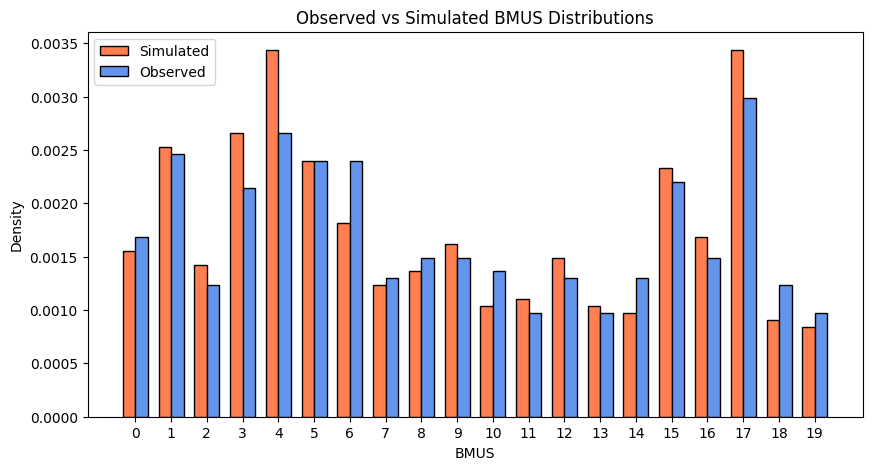

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten simulated BMUs for comparison
sim_vals = simulated_daily_bmus.evbmus_sims.values.flatten() - 2
fit_vals = xds_bmus_fit.bmus.values - 2

bmus = np.arange(0,20,1)

# Compute densities (or frequencies)
sim_counts = [np.mean(sim_vals == bmu) for bmu in bmus]
fit_counts = [np.mean(fit_vals == bmu) for bmu in bmus]

# Width for bars
width = 0.35
x = np.arange(len(bmus))

plt.figure(figsize=(10,5))
plt.bar(x - width/2, sim_counts, width, label='Simulated', color='coral', edgecolor='black')
plt.bar(x + width/2, fit_counts, width, label='Observed', color='cornflowerblue', edgecolor='black')

plt.xticks(x, bmus)
plt.xlabel('BMUS')
plt.ylabel('Density')
plt.title('Observed vs Simulated BMUS Distributions')
plt.legend()
plt.show()

## 03. Forecast GCM 

In [39]:
models = [ 'ec_earth3_veg_lr']
scenarios = ['historical', 'ssp245', 'ssp585']

ALR model fit   : 1981-09-04 --- 2023-11-22
ALR model sim   : 1979-01-31 --- 2014-12-31

Launching 5 simulations...

Sim. Num. 005: 100%|██████████| 13119/13119 [00:04<00:00, 2962.16it/s]

ALR model fit   : 1981-09-04 --- 2023-11-22
ALR model sim   : 2015-01-31 --- 2100-12-31

Launching 5 simulations...

Sim. Num. 005: 100%|██████████| 31381/31381 [00:10<00:00, 2902.81it/s]

ALR model fit   : 1981-09-04 --- 2023-11-22
ALR model sim   : 2015-01-31 --- 2100-12-31

Launching 5 simulations...

Sim. Num. 005: 100%|██████████| 31381/31381 [00:10<00:00, 2919.94it/s]



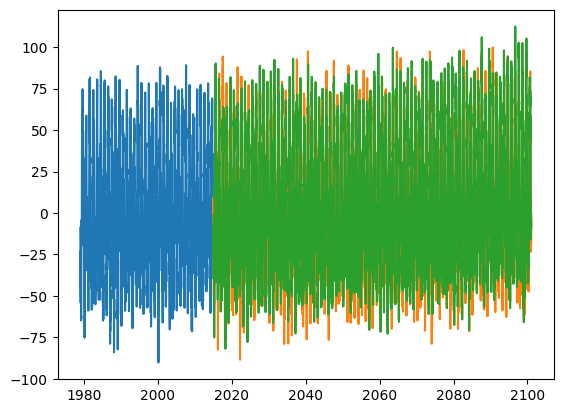

In [40]:
simulated_daily_bmus_list = []

for model in models:
    for ssp in scenarios:

        os.makedirs(f'outputs/tc_logit/{model}/{ssp}', exist_ok=True)

        gcm_pcs_mslp = pd.read_csv(f'outputs/cmip6_models/{model}/{ssp}/mslp_{model}_{ssp}_pcs.csv', index_col=0, parse_dates=True)
        gcm_pcs_mslp = gcm_pcs_mslp.iloc[:,:10]
        gcm_pcs_sst = pd.read_csv(f'outputs/cmip6_models/{model}/{ssp}/sst_{model}_{ssp}_pcs.csv', index_col=0, parse_dates=True)
        gcm_pcs_sst_detrended = detrend_dataframe(gcm_pcs_sst, degree=2)
        gcm_pcs_sst = gcm_pcs_sst_detrended.copy()

        gcm_pcs_mslp_roll = gcm_pcs_mslp.rolling("5D", center=True).mean()
        gcm_pcs_sst_roll = gcm_pcs_sst.rolling("5D", center=True).mean()

        gcm_pcs_mslp_roll = gcm_pcs_mslp_roll.add_suffix("_mslp")
        gcm_pcs_sst_roll = gcm_pcs_sst_roll.add_suffix("_sst")

        gcm_pcs_mslp_roll.index = pd.to_datetime(gcm_pcs_mslp_roll.index).normalize()
        gcm_pcs_sst_roll.index = pd.to_datetime(gcm_pcs_sst_roll.index).normalize()

        gcm_pcs_roll = gcm_pcs_mslp_roll.join(gcm_pcs_sst_roll, how="inner")

        pcs_per_sim_list = [gcm_pcs_roll]
        n_sims = 1

        time = pcs_per_sim_list[0].index
        cov_names = pcs_per_sim_list[0].columns
        n_cov = len(cov_names)

        cov_stack = np.stack([df.values for df in pcs_per_sim_list])

        covar_sim = xr.Dataset(
            data_vars=dict(
                cov_values=(("n_sim", "time", "n_covariates"), cov_stack),
                cov_names=(("n_sim", "n_covariates"),np.tile(cov_names.values, (n_sims, 1)))),
            coords=dict(n_sim=np.arange(n_sims),time=time,n_covariates=np.arange(n_cov),))
        
        covar_sim

        plt.plot(covar_sim.time.values, covar_sim.cov_values.isel(n_sim=0,n_covariates=0))
        
        for i in range(1):
            simulated_daily_bmus = alr_model.Simulate(
                num_sims=5,
                time_sim=covar_sim.time.values,
                xds_covars_sim=covar_sim.isel(n_sim=0),
            )
        
        simulated_daily_bmus.to_netcdf(f'outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_{model}_{ssp}.nc')